In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats as stats
from IPython.display import display
seed = 42

In [2]:
# data = pd.read_csv('banking.csv', header = 0)
# data.to_hdf('banking.h5', key='data', mode='w') 
data = pd.read_hdf('banking.h5', 'data')
print(data.shape)
print(list(data.columns))
display(data)

(41188, 21)
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,59,retired,married,high.school,unknown,no,yes,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0
41184,31,housemaid,married,basic.4y,unknown,no,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
41185,42,admin.,single,university.degree,unknown,yes,yes,telephone,may,wed,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
41186,48,technician,married,professional.course,no,no,yes,telephone,oct,tue,...,2,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,0


In [3]:
number_cols = list(data.select_dtypes(include='number').columns)
print("Number Columns:\n", number_cols)

object_cols = list(data.select_dtypes(include='object').columns)
print("Object Columns:\n", object_cols)

multi_cols = list(data.select_dtypes(include=['number', 'object']).columns)
print("Multi-Datatype Columns:\n", multi_cols)

exclude_cols = list(data.select_dtypes(exclude='number').columns)
print("Excluded Datatype Columns:\n", exclude_cols)

Number Columns:
 ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']
Object Columns:
 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Multi-Datatype Columns:
 ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y']
Excluded Datatype Columns:
 ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [4]:
for col in object_cols:
    data[col] = data[col].astype("category")
    
display(data[object_cols])

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,nonexistent
1,technician,married,unknown,no,no,no,cellular,nov,fri,nonexistent
2,management,single,university.degree,no,yes,no,cellular,jun,thu,success
3,services,married,high.school,no,no,no,cellular,apr,fri,nonexistent
4,retired,married,basic.4y,no,yes,no,cellular,aug,fri,success
...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,high.school,unknown,no,yes,telephone,jun,thu,nonexistent
41184,housemaid,married,basic.4y,unknown,no,no,telephone,may,thu,nonexistent
41185,admin.,single,university.degree,unknown,yes,yes,telephone,may,wed,nonexistent
41186,technician,married,professional.course,no,no,yes,telephone,oct,tue,nonexistent


In [5]:
from sklearn.model_selection import train_test_split

X = data.copy()
y = data.copy()
X = X[multi_cols]
X = X.drop('y', axis=1)
y = y['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, stratify=y, random_state=seed)

In [6]:
# The model parameters are as follows:
# base_score - This is the prediction for initial models. It has a default score of 0.5.
# booster - This is the type of algorithm that is used to improve the model performance.
# colsample_bylevel - This shows how different branches levels are separated in the tree.
# colsample_bynode - It shows how different nodes are split.
# colsample_bytree - It shows how different trees in XGBoost are separated.
# gamma - This is used to reduce the loss when correcting model errors.
# learning_rate - The rate at which the XGBoost model learns during the training phase
# max_delta_step - This is used to update the model class during training.
# max_depth - This is the maximum depth of the XGBoost classifier.
# min_child_weight - This is the minimum size we are allowed to partition the tree’s leaf node.
# n_estimators - This is the total number of estimators added during model training.
# n_jobs - This is the total number of jobs handled by the model.
# objective - It specifies the type of algorithm used to build the model, in this case, it uses logistic regression.
# random_state - This seeding number is used by the model.
# reg_alpha - This is the parameter used to reduce the weights of the model.
# reg_lambda - This is the parameter used to increase the weights of the model.
# seed - The seed used by the model.
# subsample - The ratios we use to sample the training phases of a model.
# verbosity - It measures the verbosity of words in the dataset.

In [7]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': randint(100, 600),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0.5, 3),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5),
    'tree_method': ['approx', 'hist']
}

xgb = XGBClassifier(
    objective = 'binary:logistic',
    eval_metric = 'auc',
    enable_categorical = True,
    n_jobs = -1,
    random_state = seed
)

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = seed)

random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dist,
    n_iter = 100,
    scoring = 'roc_auc',
    cv = cv, # ← StratifiedKFold uses y automatically
    refit = True, # ← refit best model on full data
    n_jobs = -1,
    random_state = seed,
    verbose = 0
)

random_search.fit(X_train, y_train)

# Print best parameters
print(f"Best hyperparameters: {random_search.best_params_}")
print(f"Best AUC: {random_search.best_score_:.6f}")
print(f"Best Gini: {2.0 * random_search.best_score_ - 1.0:.6f}")

# Extract the best trained model
model = random_search.best_estimator_

Best hyperparameters: {'colsample_bytree': 0.8264148841976305, 'gamma': 0.07932322382124551, 'learning_rate': 0.046049394341692654, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 146, 'reg_alpha': 0.08145760463794027, 'reg_lambda': 3.0663817520330214, 'subsample': 0.8814631437520095, 'tree_method': 'hist'}
Best AUC: 0.948998
Best Gini: 0.897996


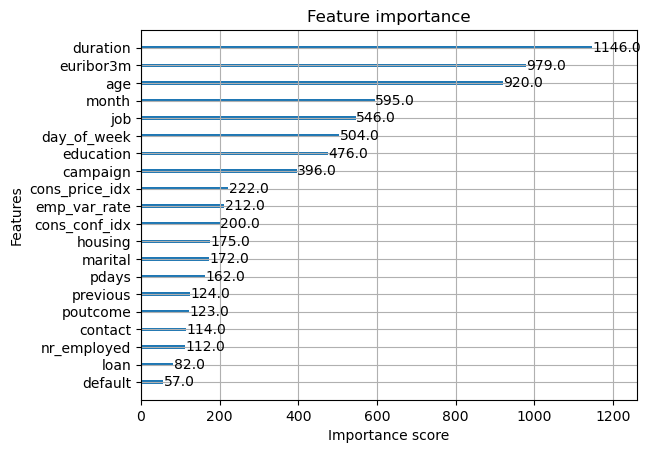

In [8]:
# Plot feature importance
from xgboost import plot_importance
plot_importance(model)
plt.show()

In [9]:
from sklearn.metrics import roc_auc_score

# Calculate probabilities
y_proba_train = model.predict_proba(X_train)[:, 1]
y_proba_test = model.predict_proba(X_test)[:, 1]

# Train set evaluation
auc_train = roc_auc_score(y_train, y_proba_train)
gini_train = 2.0 * auc_train - 1.0
print(f"Train Gini: {gini_train:.6f}")

# Test set evaluation
auc_test = roc_auc_score(y_test, y_proba_test)
gini_test = 2.0 * auc_test - 1.0
print(f"Test Gini:  {gini_test:.6f}")

Train Gini: 0.939972
Test Gini:  0.902440


In [10]:
# Save XGBoost model in native format
model.save_model("xgb_model.ubj") 

In [11]:
# Load
from xgboost import XGBClassifier
model = XGBClassifier()
model.load_model("xgb_model.ubj")

In [12]:
# Make predictions on test
y_pred = model.predict(X_test)
pd.crosstab(y_test, y_pred.astype(int), rownames=['Original'], colnames=['Predictions'])

Predictions,0,1
Original,,
0,10590,375
1,645,747


In [13]:
# Method returns histogram of splits for feature values. 
# Below we have created split values histogram for feature duration of data. 
# It gives us value and how many times a split has happened at that value.
booster = model.get_booster()
split = booster.get_split_value_histogram("duration")
split.sort_values('Count', ascending = False, inplace = True)
display(split)

,SplitValue,Count
2,85.967914,82.0
5,109.935829,44.0
37,365.593583,43.0
4,101.946524,33.0
7,125.914439,33.0
...,...,...
34,341.625668,2.0
22,245.754011,1.0
45,429.508021,1.0
40,389.561497,1.0


In [14]:
booster = model.get_booster()
split = booster.get_split_value_histogram("duration")
split.sort_values('Count', ascending = False, inplace = True)
split_points = split['SplitValue'].to_list()
bins_tree = split_points[:3]
min_val = data["duration"].describe()['min']
max_val = data["duration"].describe()['max']
bins = bins_tree
bins.append(min_val)
bins.append(max_val)
bins = list(np.round(bins, 4))
bins = list(set(bins))
bins.sort()
print(bins)

[0.0, 85.9679, 109.9358, 365.5936, 4918.0]


<Axes: xlabel='duration', ylabel='Count'>

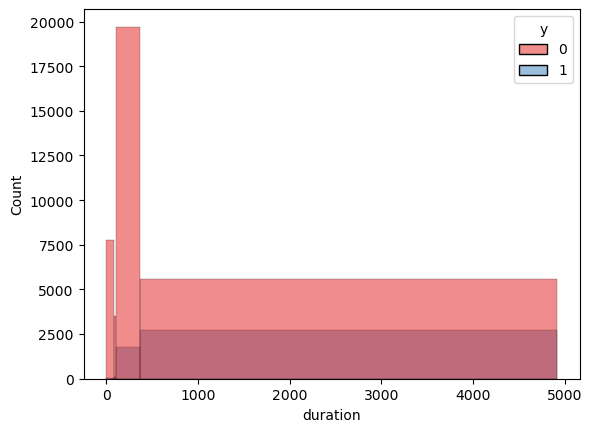

In [15]:
sns.histplot(x = "duration", hue = "y", bins = bins, data = data, palette = "Set1")